In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [41]:
df = pd.read_excel(r"C:\Users\vinaykumar\INTERNSHIP\BUYBACK DATASET.xlsx")

In [42]:
df

,timestamp,season,cloud_cover,day_type,hour,solar_generation_kWh,net_energy_kWh,battery_capacity_kWh,battery_level_kWh,buyback_demand_kWh,buyback_price
0,2024-01-01 00:00:00,Winter,48,Weekday,0,0.0,0.0,20,6,13.2,2.250808
1,2024-01-01 01:00:00,Winter,41,Weekday,1,0.0,0.0,20,6,13.2,1.991496
2,2024-01-01 02:00:00,Winter,40,Weekday,2,0.0,0.0,20,6,13.2,1.879960
3,2024-01-01 03:00:00,Winter,40,Weekday,3,0.0,0.0,20,6,13.2,1.939920
4,2024-01-01 04:00:00,Winter,43,Weekday,4,0.0,0.0,20,6,13.2,1.957984
...,...,...,...,...,...,...,...,...,...,...,...
17539,2025-12-31 19:00:00,Winter,87,Weekday,19,0.0,0.0,20,10,12.0,6.091128
17540,2025-12-31 20:00:00,Winter,72,Weekday,20,0.0,0.0,20,10,12.0,3.581824
17541,2025-12-31 21:00:00,Winter,53,Weekday,21,0.0,0.0,20,10,12.0,3.283048
17542,2025-12-31 22:00:00,Winter,46,Weekday,22,0.0,0.0,20,10,12.0,2.990392


In [43]:
df['buyback_price'].describe()

count    17544.000000
mean         3.431701
std          2.082237
min          0.049560
25%          2.156738
50%          2.743976
75%          3.802092
max          8.000000
Name: buyback_price, dtype: float64

In [44]:
df_1 = df.copy()

In [45]:
df['season'].unique()

array(['Winter', 'Summer', 'Monsoon'], dtype=object)

In [46]:
df['day_type'].unique()

array(['Weekday', 'Weekend'], dtype=object)

In [47]:
df_1

,timestamp,season,cloud_cover,day_type,hour,solar_generation_kWh,net_energy_kWh,battery_capacity_kWh,battery_level_kWh,buyback_demand_kWh,buyback_price
0,2024-01-01 00:00:00,Winter,48,Weekday,0,0.0,0.0,20,6,13.2,2.250808
1,2024-01-01 01:00:00,Winter,41,Weekday,1,0.0,0.0,20,6,13.2,1.991496
2,2024-01-01 02:00:00,Winter,40,Weekday,2,0.0,0.0,20,6,13.2,1.879960
3,2024-01-01 03:00:00,Winter,40,Weekday,3,0.0,0.0,20,6,13.2,1.939920
4,2024-01-01 04:00:00,Winter,43,Weekday,4,0.0,0.0,20,6,13.2,1.957984
...,...,...,...,...,...,...,...,...,...,...,...
17539,2025-12-31 19:00:00,Winter,87,Weekday,19,0.0,0.0,20,10,12.0,6.091128
17540,2025-12-31 20:00:00,Winter,72,Weekday,20,0.0,0.0,20,10,12.0,3.581824
17541,2025-12-31 21:00:00,Winter,53,Weekday,21,0.0,0.0,20,10,12.0,3.283048
17542,2025-12-31 22:00:00,Winter,46,Weekday,22,0.0,0.0,20,10,12.0,2.990392


In [48]:
# Convert timestamp
df_1['timestamp'] = pd.to_datetime(df_1['timestamp'])
df_1 = df.sort_values(by='timestamp')

#  Encode season
season_map = {'Winter': 0, 'Summer': 1, 'Monsoon': 2}
df_1['season'] = df_1['season'].map(season_map)

#  Encode day_type
day_map = {'Weekday': 0, 'Weekend': 1}
df_1['day_type'] = df_1['day_type'].map(day_map)

In [49]:
features = ['season', 'hour', 'day_type', 'buyback_demand_kWh']
target = 'buyback_price'

# Step 1: copy dataset
df = df_1.copy()

# Step 2: sort by time
df = df.sort_values(by='timestamp')

# Step 3: split 80/20
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [50]:
def train_model_cached(train, features, target):
    from statsmodels.tsa.statespace.sarimax import SARIMAX

    model = SARIMAX(
        train[target],
        exog=train[features],
        order=(1,1,1),
        seasonal_order=(1,1,1,24)
    )

    return model.fit(disp=False)

In [51]:
# Use full dataset (both 2024 + 2025)
df = df_1.copy()

# Sort by time
df = df.sort_values(by='timestamp')

# 80% train, 20% test
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

In [52]:
future_dates = pd.date_range(start='2026-01-01', end='2026-01-07 23:00', freq='H')

future_df = pd.DataFrame({'timestamp': future_dates})

# Hour
future_df['hour'] = future_df['timestamp'].dt.hour

# Day type
future_df['day_type'] = future_df['timestamp'].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)

# Season (Jan → Winter)
future_df['season'] = 0

# Grid demand (simple assumption → use last known pattern)
future_df['buyback_demand_kWh'] = df_1['buyback_demand_kWh'].tail(len(future_df)).values

C:\Users\vinaykumar\AppData\Local\Temp\ipykernel_20460\1424261213.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  future_dates = pd.date_range(start='2026-01-01', end='2026-01-07 23:00', freq='H')


In [53]:

if 'model_fit' not in globals():
    model_fit = train_model_cached(train, features, target)
    
y_pred = model_fit.predict(
    start=len(train),
    end=len(train)+len(test)-1,
    exog=X_test
)

# Accuracy check
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)

print("Test MAE:", mae)

forecast_sarimax = model_fit.forecast(
    steps=len(future_df),
    exog=future_df[features]
)

Test MAE: 3.9231860433371963


In [65]:
future_df['SARIMAX'] = forecast_sarimax.values[:len(future_df)]

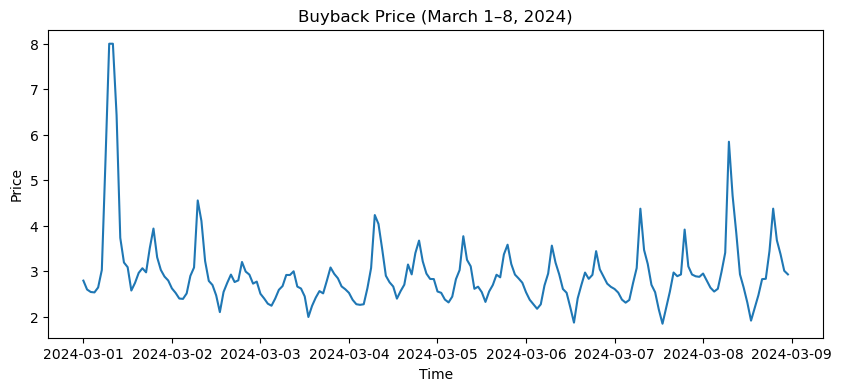

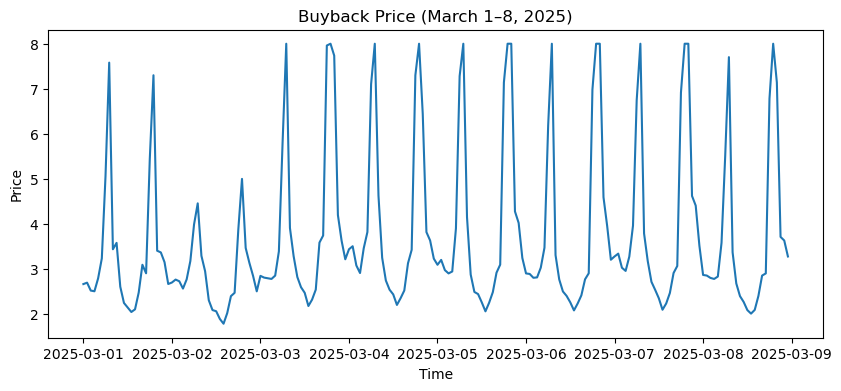

In [66]:
import matplotlib.pyplot as plt

df_temp = df.copy()
df_temp = df_temp.set_index('timestamp')
# Filter data
march_2024 = df_temp[(df_temp.index.year == 2024) &
                     (df_temp.index.month == 3) &
                     (df_temp.index.day <= 8)]

march_2025 = df_temp[(df_temp.index.year == 2025) &
                     (df_temp.index.month == 3) &
                     (df_temp.index.day <= 8)]

# Plot 2024
plt.figure(figsize=(10,4))
plt.plot(march_2024[target])
plt.title("Buyback Price (March 1–8, 2024)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

# Plot 2025
plt.figure(figsize=(10,4))
plt.plot(march_2025[target])
plt.title("Buyback Price (March 1–8, 2025)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

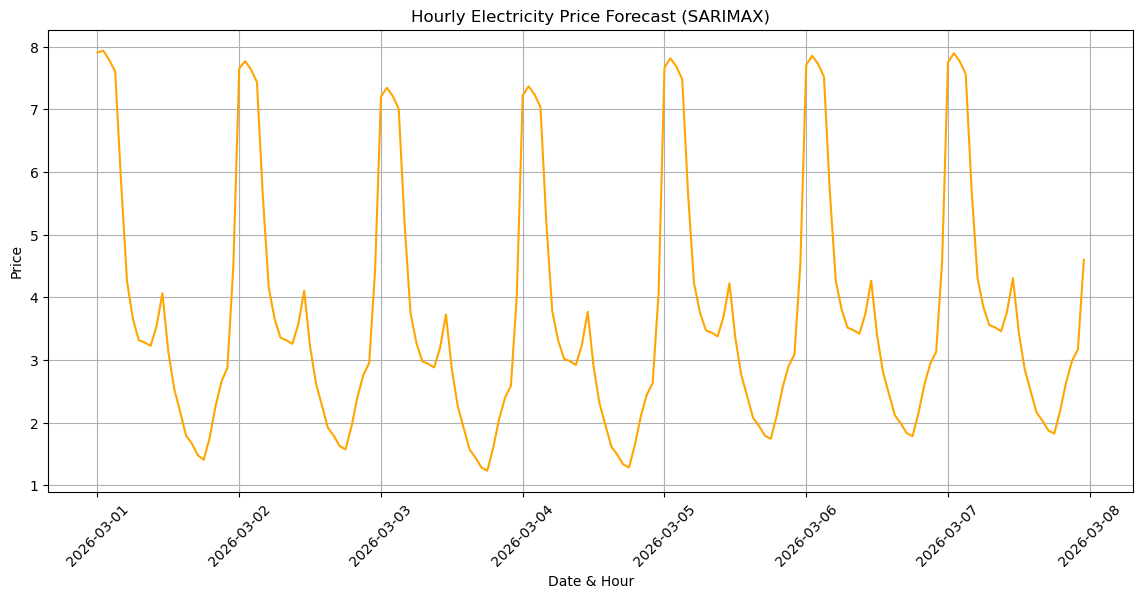

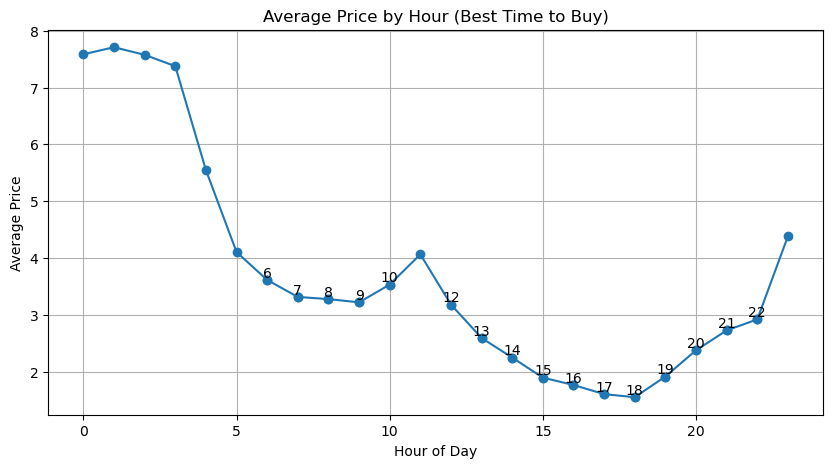

BEST HOURS TO BUY (Lowest Prices):
hour
18    1.548182
17    1.602491
16    1.763481
15    1.892516
19    1.912591
Name: SARIMAX, dtype: float64


In [67]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Combine forecast with time info
forecast_df = future_df.copy()
forecast_df['hour'] = forecast_df['timestamp'].dt.hour
forecast_df['date'] = forecast_df['timestamp'].dt.date

forecast_df = forecast_df[
    (forecast_df['timestamp'] >= '2026-03-01') & 
    (forecast_df['timestamp'] < '2026-03-09')   # IMPORTANT change
]

# -----------------------------
# 1. Plot Hourly Forecast (Better View)
# -----------------------------
plt.figure(figsize=(14,6))

plt.plot(forecast_df['timestamp'], forecast_df['SARIMAX'], color='orange')

plt.title("Hourly Electricity Price Forecast (SARIMAX)")
plt.xlabel("Date & Hour")
plt.ylabel("Price")

# Rotate for readability
plt.xticks(rotation=45)

plt.grid(True)
plt.show()

# -----------------------------
# 2. Average Price by Hour (KEY INSIGHT)
# -----------------------------
hourly_avg = forecast_df.groupby('hour')['SARIMAX'].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')

plt.title("Average Price by Hour (Best Time to Buy)")
plt.xlabel("Hour of Day")
plt.ylabel("Average Price")
plt.grid(True)

# Highlight cheapest hours
low_threshold = hourly_avg.mean()
low_hours = hourly_avg[hourly_avg < low_threshold]

plt.scatter(low_hours.index, low_hours.values)

for h in low_hours.index:
    plt.text(h, low_hours[h], f"{h}", ha='center', va='bottom')

plt.show()

# -----------------------------
# 3. Show BEST HOURS TO BUY
# -----------------------------
best_hours = hourly_avg.nsmallest(5)

print("BEST HOURS TO BUY (Lowest Prices):")
print(best_hours)

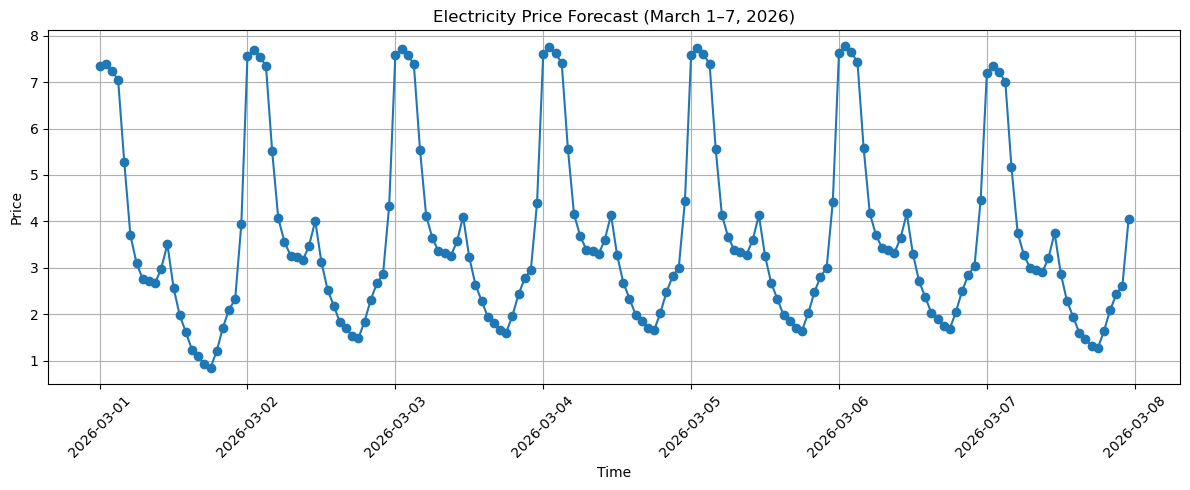

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 1. Create Future Data
# ==============================
def create_future_dataframe(start_date, end_date, df):

    # Generate hourly timestamps
    future_dates = pd.date_range(start=start_date, end=end_date, freq='h')

    future_df = pd.DataFrame({'timestamp': future_dates})

    # Hour feature
    future_df['hour'] = future_df['timestamp'].dt.hour

    # Day type (Weekend = 1, Weekday = 0)
    future_df['day_type'] = future_df['timestamp'].dt.weekday.apply(
        lambda x: 1 if x >= 5 else 0
    )

    # Season encoding
    def get_season(month):
        if month in [12, 1, 2]:
            return 0   # Winter
        elif month in [3, 4, 5]:
            return 1   # Summer
        else:
            return 2   # Monsoon

    future_df['season'] = future_df['timestamp'].dt.month.apply(get_season)

    # Demand (reuse recent pattern safely)
    demand_values = df['buyback_demand_kWh'].tail(len(future_df)).values

    # If not enough rows, repeat values
    if len(demand_values) < len(future_df):
        demand_values = pd.Series(demand_values).repeat(
            (len(future_df) // len(demand_values)) + 1
        ).values[:len(future_df)]

    future_df['buyback_demand_kWh'] = demand_values

    return future_df


# ==============================
# 2. Generate Future Data
# ==============================
future_df = create_future_dataframe(
    start_date='2026-03-01 00:00',
    end_date='2026-03-07 23:00',
    df=df_1
)


# ==============================
# 3. Forecast using SARIMAX
# ==============================
forecast = model_fit.forecast(
    steps=len(future_df),
    exog=future_df[features]
)

future_df['Forecast_Price'] = forecast.values


# ==============================
# 4. Plot Graph
# ==============================
plt.figure(figsize=(12,5))

plt.plot(
    future_df['timestamp'],
    future_df['Forecast_Price'],
    marker='o',
    linestyle='-'
)

plt.title("Electricity Price Forecast (March 1–7, 2026)")
plt.xlabel("Time")
plt.ylabel("Price")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [58]:
future_df['Forecast_Price'].describe()

count    168.000000
mean       3.665422
std        1.962480
min        0.855541
25%        2.267254
50%        3.226325
75%        4.160616
max        7.766266
Name: Forecast_Price, dtype: float64

In [59]:
high_threshold = future_df['Forecast_Price'].quantile(0.75)
medium_threshold = future_df['Forecast_Price'].quantile(0.50)

In [60]:
def buyback_decision(price):
    if price >= high_threshold:
        return "BATTERY"          # very expensive → use battery
    elif price >= medium_threshold:
        return "BATTERY_PARTIAL"  # medium → partial battery usage
    else:
        return "GRID"             # cheap → use grid

In [61]:
future_df["Forecast_Decision"] = future_df["Forecast_Price"].apply(buyback_decision)

In [62]:
future_df['Date'] = future_df['timestamp'].dt.date
future_df['Hour_Time'] = future_df['timestamp'].dt.strftime('%I %p').str.lstrip('0')

In [63]:
result = future_df[['Date', 'Hour_Time', 'Forecast_Price', 'Forecast_Decision']]
print(result.to_string())

           Date Hour_Time  Forecast_Price Forecast_Decision
0    2026-03-01     12 AM        7.353330           BATTERY
1    2026-03-01      1 AM        7.381339           BATTERY
2    2026-03-01      2 AM        7.233783           BATTERY
3    2026-03-01      3 AM        7.051025           BATTERY
4    2026-03-01      4 AM        5.280327           BATTERY
5    2026-03-01      5 AM        3.704500   BATTERY_PARTIAL
6    2026-03-01      6 AM        3.103090              GRID
7    2026-03-01      7 AM        2.762213              GRID
8    2026-03-01      8 AM        2.724871              GRID
9    2026-03-01      9 AM        2.674238              GRID
10   2026-03-01     10 AM        2.986066              GRID
11   2026-03-01     11 AM        3.511284   BATTERY_PARTIAL
12   2026-03-01     12 PM        2.578031              GRID
13   2026-03-01      1 PM        1.981746              GRID
14   2026-03-01      2 PM        1.620658              GRID
15   2026-03-01      3 PM        1.24040